<a href="https://colab.research.google.com/github/padhab34-bit/IML/blob/main/HW5Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

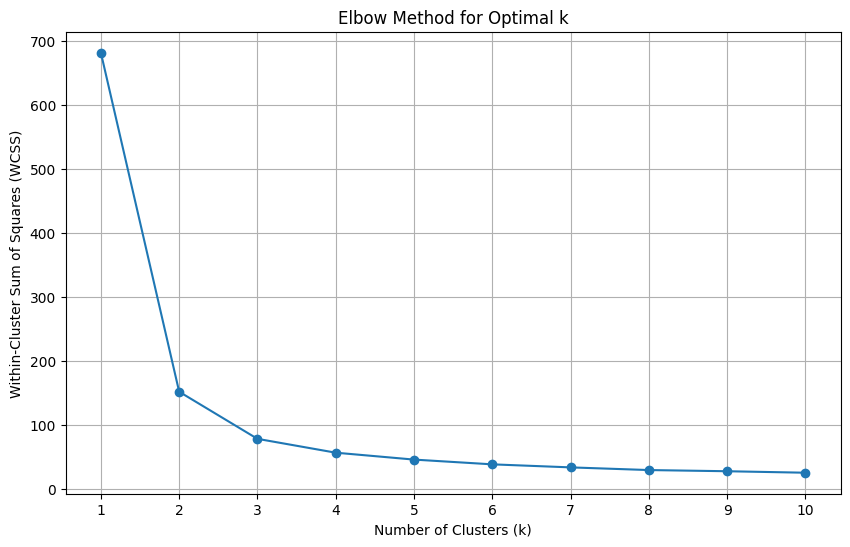

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data

wcss = []

k_range = range(1, 11)

# Calculate WCSS for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# plot the lbow graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

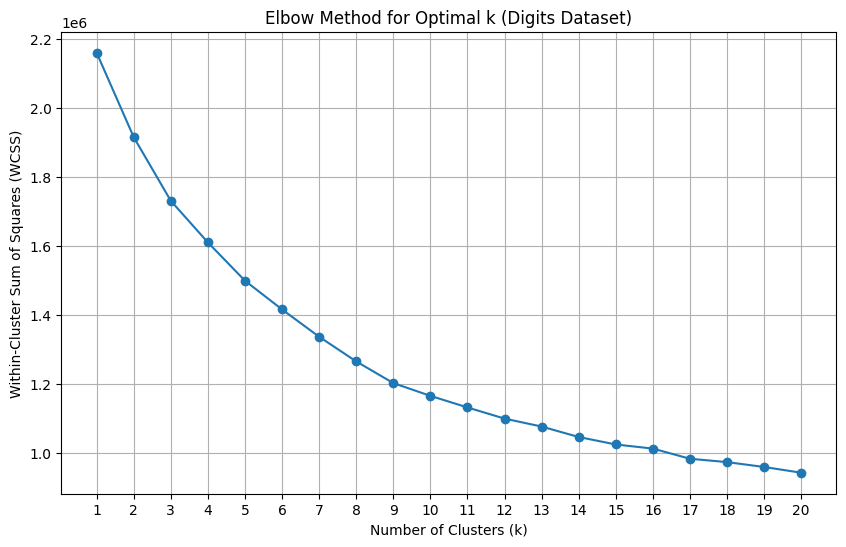

In [2]:
from sklearn.datasets import load_digits

# Load the Digits dataset
digits = load_digits()
X_digits = digits.data

# Store WCSS values for different k
wcss_digits = []

# Define a range of k values to test for digits (0-9, so up to 20 or so)
k_range_digits = range(1, 21)

# Calculate WCSS for each k
for k in k_range_digits:
    kmeans_digits = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_digits.fit(X_digits)
    wcss_digits.append(kmeans_digits.inertia_)

# Plot the Elbow Method graph for Digits
plt.figure(figsize=(10, 6))
plt.plot(k_range_digits, wcss_digits, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k (Digits Dataset)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range_digits)
plt.grid(True)
plt.show()

In [3]:

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import time
import numpy as np


print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist, y_mnist = mnist.data, mnist.target
print(f"MNIST dataset loaded. X_mnist shape: {X_mnist.shape}, y_mnist shape: {y_mnist.shape}")

Loading MNIST dataset...
MNIST dataset loaded. X_mnist shape: (70000, 784), y_mnist shape: (70000,)


In [4]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X_mnist, y_mnist, test_size=0.2, random_state=42)
print(f"Data split. X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Data split. X_train shape: (56000, 784), X_test shape: (14000, 784)


In [5]:
# apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaled using StandardScaler.")

Data scaled using StandardScaler.


#### Logistic Regression Without PCA

In [6]:
print("Training Logistic Regression without PCA...")
start_time_no_pca = time.time()

logisticRegr_no_pca = LogisticRegression(solver='lbfgs', max_iter=1000, n_jobs=-1) # Increased max_iter for convergence, n_jobs for parallel processing
logisticRegr_no_pca.fit(X_train_scaled, y_train)

end_time_no_pca = time.time()
time_no_pca = end_time_no_pca - start_time_no_pca

y_pred_no_pca = logisticRegr_no_pca.predict(X_test_scaled)
accuracy_no_pca = accuracy_score(y_test, y_pred_no_pca)

print(f"Logistic Regression (without PCA) training time: {time_no_pca:.2f} seconds")
print(f"Logistic Regression (without PCA) accuracy: {accuracy_no_pca:.4f}")

Training Logistic Regression without PCA...
Logistic Regression (without PCA) training time: 44.54 seconds
Logistic Regression (without PCA) accuracy: 0.9154


In [7]:
print("Applying PCA (n_components=0.95)...")
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced dimensions (after PCA): {X_train_pca.shape[1]}")
print("PCA applied.")

Applying PCA (n_components=0.95)...
Original dimensions: 784
Reduced dimensions (after PCA): 330
PCA applied.


In [8]:
print("Training Logistic Regression with PCA...")
start_time_pca = time.time()

logisticRegr_pca = LogisticRegression(solver='lbfgs', max_iter=1000, n_jobs=-1)
logisticRegr_pca.fit(X_train_pca, y_train)

end_time_pca = time.time()
time_pca = end_time_pca - start_time_pca

y_pred_pca = logisticRegr_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Logistic Regression (with PCA) training time: {time_pca:.2f} seconds")
print(f"Logistic Regression (with PCA) accuracy: {accuracy_pca:.4f}")

Training Logistic Regression with PCA...
Logistic Regression (with PCA) training time: 35.91 seconds
Logistic Regression (with PCA) accuracy: 0.9217


In [9]:
print("\n--- Comparison ---")
print(f"Without PCA: Time = {time_no_pca:.2f}s, Accuracy = {accuracy_no_pca:.4f}")
print(f"With PCA:    Time = {time_pca:.2f}s, Accuracy = {accuracy_pca:.4f}")

if time_no_pca > time_pca:
    print(f"PCA sped up training by: {time_no_pca - time_pca:.2f} seconds ({((time_no_pca - time_pca) / time_no_pca) * 100:.2f}% reduction)")
else:
    print("PCA did not significantly speed up training in this instance.")

print(f"Accuracy difference (No PCA - With PCA): {accuracy_no_pca - accuracy_pca:.4f}")
print("As expected, PCA can significantly reduce training time while often maintaining a comparable (or slightly reduced) accuracy.")


--- Comparison ---
Without PCA: Time = 44.54s, Accuracy = 0.9154
With PCA:    Time = 35.91s, Accuracy = 0.9217
PCA sped up training by: 8.63 seconds (19.37% reduction)
Accuracy difference (No PCA - With PCA): -0.0063
As expected, PCA can significantly reduce training time while often maintaining a comparable (or slightly reduced) accuracy.
